In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [2]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
     

In [3]:
df.head()
     

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df.drop('target', axis=1))

In [5]:
df.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [ ]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
     

In [ ]:
df.head()
     

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df.drop('target', axis=1))

In [ ]:
df.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

In [ ]:
def kmeans_clustering(n_clusters, init_method='k-means++', n_init=10, max_iter=300):
    kmeans = KMeans(n_clusters=n_clusters, init=init_method, n_init=n_init, max_iter=max_iter, random_state=42)
    labels = kmeans.fit_predict(scaled_data)
    return labels, kmeans.cluster_centers_

In [ ]:
from joblib import parallel_backend

with parallel_backend('loky', n_jobs=4):  # Specify the number of cores here
    kmeans_labels_default, centers_default = kmeans_clustering(n_clusters=2)
    kmeans_labels_custom1, centers_custom1 = kmeans_clustering(n_clusters=3, init_method='random', n_init=20, max_iter=500)
    kmeans_labels_custom2, centers_custom2 = kmeans_clustering(n_clusters=4, init_method='random', n_init=10, max_iter=300)


C:\Users\pemos\AppData\Local\Temp\ipykernel_40268\884382132.py:8: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(scaled_data[members, 0], scaled_data[members, 1], label=f'Cluster {k}', cmap='viridis')
C:\Users\pemos\AppData\Local\Temp\ipykernel_40268\884382132.py:17: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(scaled_data[members, 0], scaled_data[members, 1], label=f'Cluster {k}', cmap='viridis')
C:\Users\pemos\AppData\Local\Temp\ipykernel_40268\884382132.py:26: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(scaled_data[members, 0], scaled_data[members, 1], label=f'Cluster {k}', cmap='viridis')


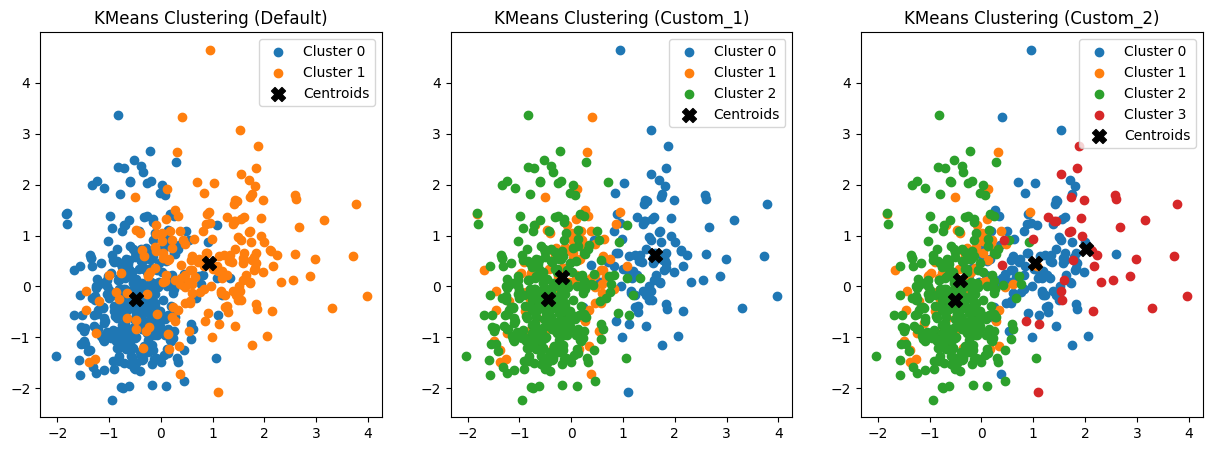

In [ ]:
# Plotting
plt.figure(figsize=(15, 5))

# Subplot 1
plt.subplot(1, 3, 1)
for k in range(2):  # Assuming n_clusters=2 for the default case
    members = kmeans_labels_default == k
    plt.scatter(scaled_data[members, 0], scaled_data[members, 1], label=f'Cluster {k}', cmap='viridis')
plt.scatter(centers_default[:, 0], centers_default[:, 1], marker='X', s=100, color='black', label='Centroids')
plt.title('KMeans Clustering (Default)')
plt.legend()

# Subplot 2
plt.subplot(1, 3, 2)
for k in range(3):  # Assuming n_clusters=3 for custom1 case
    members = kmeans_labels_custom1 == k
    plt.scatter(scaled_data[members, 0], scaled_data[members, 1], label=f'Cluster {k}', cmap='viridis')
plt.scatter(centers_custom1[:, 0], centers_custom1[:, 1], marker='X', s=100, color='black', label='Centroids')
plt.title('KMeans Clustering (Custom_1)')
plt.legend()

# Subplot 3
plt.subplot(1, 3, 3)
for k in range(4):  # Assuming n_clusters=4 for custom2 case
    members = kmeans_labels_custom2 == k
    plt.scatter(scaled_data[members, 0], scaled_data[members, 1], label=f'Cluster {k}', cmap='viridis')
plt.scatter(centers_custom2[:, 0], centers_custom2[:, 1], marker='X', s=100, color='black', label='Centroids')
plt.title('KMeans Clustering (Custom_2)')
plt.legend()

plt.show()
     

In [ ]:
def agglomerative_clustering(n_clusters, metric='euclidean', linkage='ward'):
    agg_clustering = AgglomerativeClustering(n_clusters=n_clusters, metric=metric, linkage=linkage)
    labels = agg_clustering.fit_predict(scaled_data)
    return labels


In [ ]:
agg_labels_default = agglomerative_clustering(n_clusters=2)
agg_labels_custom1 = agglomerative_clustering(n_clusters=3, metric='manhattan', linkage='complete')
agg_labels_custom2 = agglomerative_clustering(n_clusters=4, metric='euclidean', linkage='average')


In [ ]:
# Evaluate clustering results using Silhouette Score and Davies-Bouldin Index
silhouette_kmeans_default = silhouette_score(scaled_data, kmeans_labels_default)
silhouette_kmeans_custom1 = silhouette_score(scaled_data, kmeans_labels_custom1)
silhouette_kmeans_custom2 = silhouette_score(scaled_data, kmeans_labels_custom2)


silhouette_agg_default = silhouette_score(scaled_data, agg_labels_default)
silhouette_agg_custom1 = silhouette_score(scaled_data, agg_labels_custom1)
silhouette_agg_custom2 = silhouette_score(scaled_data, agg_labels_custom2)


db_index_kmeans_default = davies_bouldin_score(scaled_data, kmeans_labels_default)
db_index_kmeans_custom1 = davies_bouldin_score(scaled_data, kmeans_labels_custom1)
db_index_kmeans_custom2 = davies_bouldin_score(scaled_data, kmeans_labels_custom2)


db_index_agg_default = davies_bouldin_score(scaled_data, agg_labels_default)
db_index_agg_custom1 = davies_bouldin_score(scaled_data, agg_labels_custom1)
db_index_agg_custom2 = davies_bouldin_score(scaled_data, agg_labels_custom2)


In [ ]:
# Comparison of the two algorithms
print("KMeans Silhouette Score (default):", silhouette_kmeans_default)
print("KMeans Silhouette Score (custom1):", silhouette_kmeans_custom1)
print("KMeans Silhouette Score (custom2):", silhouette_kmeans_custom2)
print("Agglomerative Silhouette Score (default):", silhouette_agg_default)
print("Agglomerative Silhouette Score (custom1):", silhouette_agg_custom1)
print("Agglomerative Silhouette Score (custom2):", silhouette_agg_custom2)


print("KMeans Davies-Bouldin Index (default):", db_index_kmeans_default)
print("KMeans Davies-Bouldin Index (custom1):", db_index_kmeans_custom1)
print("KMeans Davies-Bouldin Index (custom2):", db_index_kmeans_custom2)
print("Agglomerative Davies-Bouldin Index (default):", db_index_agg_default)
print("Agglomerative Davies-Bouldin Index (custom1):", db_index_agg_custom1)
print("Agglomerative Davies-Bouldin Index (custom2):", db_index_agg_custom2)

KMeans Silhouette Score (default): 0.34338224069077816
KMeans Silhouette Score (custom1): 0.3143840098608098
KMeans Silhouette Score (custom2): 0.2709707980860061
Agglomerative Silhouette Score (default): 0.33938477753669855
Agglomerative Silhouette Score (custom1): 0.34452963740927434
Agglomerative Silhouette Score (custom2): 0.5543106410155653
KMeans Davies-Bouldin Index (default): 1.3205098372342035
KMeans Davies-Bouldin Index (custom1): 1.5293883767807952
KMeans Davies-Bouldin Index (custom2): 1.512986711941396
Agglomerative Davies-Bouldin Index (default): 1.369963541894103
Agglomerative Davies-Bouldin Index (custom1): 1.3925210327494664
Agglomerative Davies-Bouldin Index (custom2): 0.5036537858413066


In [6]:
def kmeans_clustering(n_clusters, init_method='k-means++', n_init=10, max_iter=300):
    kmeans = KMeans(n_clusters=n_clusters, init=init_method, n_init=n_init, max_iter=max_iter, random_state=42)
    labels = kmeans.fit_predict(scaled_data)
    return labels, kmeans.cluster_centers_

In [ ]:
from joblib import parallel_backend

with parallel_backend('loky', n_jobs=4):  
    kmeans_labels_default, centers_default = kmeans_clustering(n_clusters=2)
    kmeans_labels_custom1, centers_custom1 = kmeans_clustering(n_clusters=3, init_method='random', n_init=20, max_iter=500)
    kmeans_labels_custom2, centers_custom2 = kmeans_clustering(n_clusters=4, init_method='random', n_init=10, max_iter=300)


C:\Users\pemos\AppData\Local\Temp\ipykernel_40268\884382132.py:8: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(scaled_data[members, 0], scaled_data[members, 1], label=f'Cluster {k}', cmap='viridis')
C:\Users\pemos\AppData\Local\Temp\ipykernel_40268\884382132.py:17: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(scaled_data[members, 0], scaled_data[members, 1], label=f'Cluster {k}', cmap='viridis')
C:\Users\pemos\AppData\Local\Temp\ipykernel_40268\884382132.py:26: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(scaled_data[members, 0], scaled_data[members, 1], label=f'Cluster {k}', cmap='viridis')


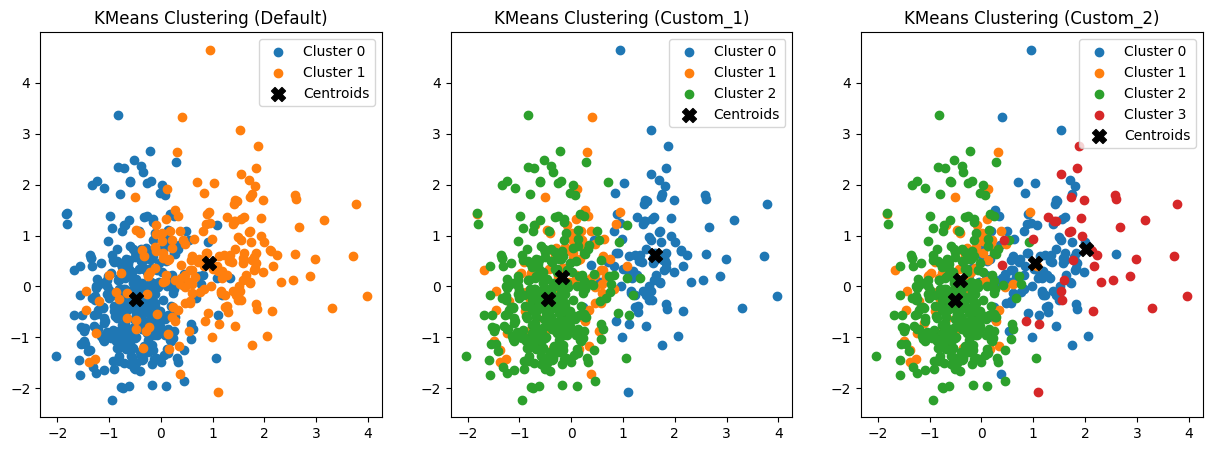

In [ ]:
# Plotting
plt.figure(figsize=(15, 5))

# Subplot 1
plt.subplot(1, 3, 1)
for k in range(2):  
    members = kmeans_labels_default == k
    plt.scatter(scaled_data[members, 0], scaled_data[members, 1], label=f'Cluster {k}', cmap='viridis')
plt.scatter(centers_default[:, 0], centers_default[:, 1], marker='X', s=100, color='black', label='Centroids')
plt.title('KMeans Clustering (Default)')
plt.legend()

# Subplot 2
plt.subplot(1, 3, 2)
for k in range(3):  
    members = kmeans_labels_custom1 == k
    plt.scatter(scaled_data[members, 0], scaled_data[members, 1], label=f'Cluster {k}', cmap='viridis')
plt.scatter(centers_custom1[:, 0], centers_custom1[:, 1], marker='X', s=100, color='black', label='Centroids')
plt.title('KMeans Clustering (Custom_1)')
plt.legend()

# Subplot 3
plt.subplot(1, 3, 3)
for k in range(4):  
    members = kmeans_labels_custom2 == k
    plt.scatter(scaled_data[members, 0], scaled_data[members, 1], label=f'Cluster {k}', cmap='viridis')
plt.scatter(centers_custom2[:, 0], centers_custom2[:, 1], marker='X', s=100, color='black', label='Centroids')
plt.title('KMeans Clustering (Custom_2)')
plt.legend()

plt.show()
     

In [18]:
def agglomerative_clustering(n_clusters, metric='euclidean', linkage='ward'):
    agg_clustering = AgglomerativeClustering(n_clusters=n_clusters, metric=metric, linkage=linkage)
    labels = agg_clustering.fit_predict(scaled_data)
    return labels


In [20]:
agg_labels_default = agglomerative_clustering(n_clusters=2)
agg_labels_custom1 = agglomerative_clustering(n_clusters=3, metric='manhattan', linkage='complete')
agg_labels_custom2 = agglomerative_clustering(n_clusters=4, metric='euclidean', linkage='average')


C:\Users\pemos\AppData\Local\Temp\ipykernel_40268\3568249537.py:8: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(scaled_data[members, 0], scaled_data[members, 1], label=f'Cluster {k}', cmap='viridis')
C:\Users\pemos\AppData\Local\Temp\ipykernel_40268\3568249537.py:16: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(scaled_data[members, 0], scaled_data[members, 1], label=f'Cluster {k}', cmap='viridis')
C:\Users\pemos\AppData\Local\Temp\ipykernel_40268\3568249537.py:24: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(scaled_data[members, 0], scaled_data[members, 1], label=f'Cluster {k}', cmap='viridis')


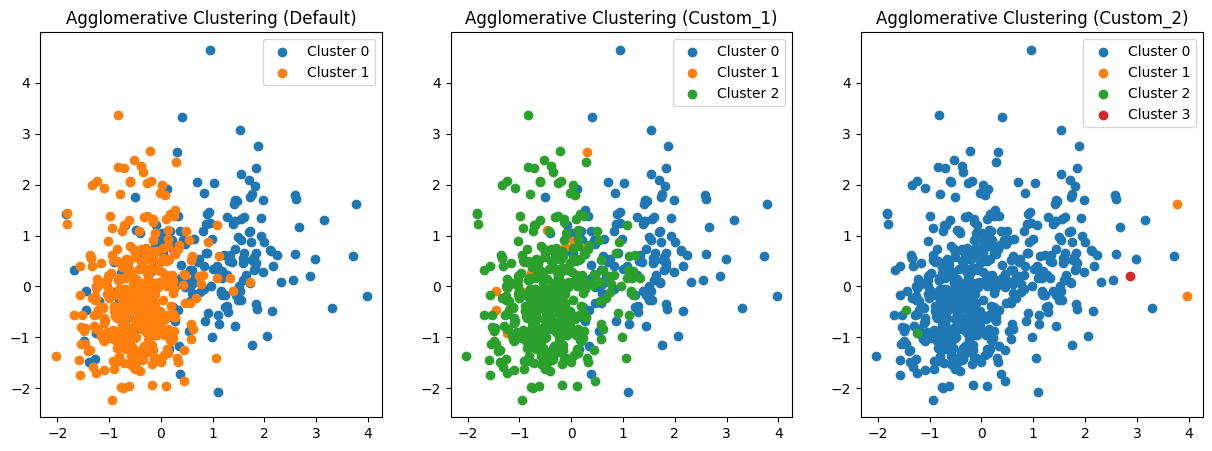

In [21]:
# Visualization of the results
plt.figure(figsize=(15, 5))

# Subplot 1
plt.subplot(1, 3, 1)
for k in range(2):  # Assuming n_clusters=2 for the default case
    members = agg_labels_default == k
    plt.scatter(scaled_data[members, 0], scaled_data[members, 1], label=f'Cluster {k}', cmap='viridis')
plt.title('Agglomerative Clustering (Default)')
plt.legend()

# Subplot 2
plt.subplot(1, 3, 2)
for k in range(3):  # Assuming n_clusters=3 for custom1 case
    members = agg_labels_custom1 == k
    plt.scatter(scaled_data[members, 0], scaled_data[members, 1], label=f'Cluster {k}', cmap='viridis')
plt.title('Agglomerative Clustering (Custom_1)')
plt.legend()

# Subplot 3
plt.subplot(1, 3, 3)
for k in range(4):  # Assuming n_clusters=4 for custom2 case
    members = agg_labels_custom2 == k
    plt.scatter(scaled_data[members, 0], scaled_data[members, 1], label=f'Cluster {k}', cmap='viridis')
plt.title('Agglomerative Clustering (Custom_2)')
plt.legend()

plt.show()

In [23]:
# Evaluate clustering results using Silhouette Score and Davies-Bouldin Index
silhouette_kmeans_default = silhouette_score(scaled_data, kmeans_labels_default)
silhouette_kmeans_custom1 = silhouette_score(scaled_data, kmeans_labels_custom1)
silhouette_kmeans_custom2 = silhouette_score(scaled_data, kmeans_labels_custom2)


silhouette_agg_default = silhouette_score(scaled_data, agg_labels_default)
silhouette_agg_custom1 = silhouette_score(scaled_data, agg_labels_custom1)
silhouette_agg_custom2 = silhouette_score(scaled_data, agg_labels_custom2)


db_index_kmeans_default = davies_bouldin_score(scaled_data, kmeans_labels_default)
db_index_kmeans_custom1 = davies_bouldin_score(scaled_data, kmeans_labels_custom1)
db_index_kmeans_custom2 = davies_bouldin_score(scaled_data, kmeans_labels_custom2)


db_index_agg_default = davies_bouldin_score(scaled_data, agg_labels_default)
db_index_agg_custom1 = davies_bouldin_score(scaled_data, agg_labels_custom1)
db_index_agg_custom2 = davies_bouldin_score(scaled_data, agg_labels_custom2)


In [24]:
# Comparison of the two algorithms
print("KMeans Silhouette Score (default):", silhouette_kmeans_default)
print("KMeans Silhouette Score (custom1):", silhouette_kmeans_custom1)
print("KMeans Silhouette Score (custom2):", silhouette_kmeans_custom2)
print("Agglomerative Silhouette Score (default):", silhouette_agg_default)
print("Agglomerative Silhouette Score (custom1):", silhouette_agg_custom1)
print("Agglomerative Silhouette Score (custom2):", silhouette_agg_custom2)


print("KMeans Davies-Bouldin Index (default):", db_index_kmeans_default)
print("KMeans Davies-Bouldin Index (custom1):", db_index_kmeans_custom1)
print("KMeans Davies-Bouldin Index (custom2):", db_index_kmeans_custom2)
print("Agglomerative Davies-Bouldin Index (default):", db_index_agg_default)
print("Agglomerative Davies-Bouldin Index (custom1):", db_index_agg_custom1)
print("Agglomerative Davies-Bouldin Index (custom2):", db_index_agg_custom2)

KMeans Silhouette Score (default): 0.34338224069077816
KMeans Silhouette Score (custom1): 0.3143840098608098
KMeans Silhouette Score (custom2): 0.2709707980860061
Agglomerative Silhouette Score (default): 0.33938477753669855
Agglomerative Silhouette Score (custom1): 0.34452963740927434
Agglomerative Silhouette Score (custom2): 0.5543106410155653
KMeans Davies-Bouldin Index (default): 1.3205098372342035
KMeans Davies-Bouldin Index (custom1): 1.5293883767807952
KMeans Davies-Bouldin Index (custom2): 1.512986711941396
Agglomerative Davies-Bouldin Index (default): 1.369963541894103
Agglomerative Davies-Bouldin Index (custom1): 1.3925210327494664
Agglomerative Davies-Bouldin Index (custom2): 0.5036537858413066
